# Model Comparison: Custom CNN vs ResNet50 + Ensemble

Evaluates the two final models — **Custom CNN C3 (Tuned)** and **ResNet50 C2 (Improved)** — individually on the held-out test set, then combines their predictions via probability averaging (simple average + validation-tuned weighted average) to check whether ensembling beats either model alone.

**Note on methodology:** the ensemble weight is chosen using the **validation set only** (never the test set), and test accuracy is reported exactly once per final configuration. This avoids using test-set performance to make any selection decision — the same principle flagged earlier for picking a "best" model.

## 1. Setup

In [1]:
# Standard library
import os
import random
import glob
from pathlib import Path

# Third-party
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.regularizers import L2

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")

2026-07-23 04:03:24.621752: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-07-23 04:03:24.643688: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8473] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-07-23 04:03:24.650734: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1471] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-07-23 04:03:24.667123: I tensorflow/core/platform/cpu_feature_guard.cc:211] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE3 SSE4.1 SSE4.2 AVX, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow version: 2.17.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


I0000 00:00:1784779406.779947   21892 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:06:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1784779406.854145   21892 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:06:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1784779406.854224   21892 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:06:00.0/numa_node
Your kernel may have been built without NUMA support.


In [2]:
# ============================================================
# GLOBAL CONFIGURATION
# ============================================================

DATASET_PATH = Path("/workspaces/ODL_ASSIGNMENT/ODL/dataset")  # <-- update if needed

SEED = 42
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = 6

# Checkpoints saved by 02_cnn_training.ipynb and (resnet) training notebook.
# Update these paths if your checkpoints live somewhere else.
CNN_C3_CKPT = "checkpoints/cnn_c3_best.h5"
RESNET_C2_CKPT = "checkpoints/res_c2_best.h5"

# Set random seeds for reproducibility
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Configuration set.")

Configuration set.


## 2. Data Pipeline

Same stratified 70/15/15 split (`random_state=47`) used in the training notebooks, so the test set here is identical to the one each model was already evaluated on — this is what makes the comparison and ensemble valid.

In [3]:
def load_dataset(dataset_path: Path) -> pd.DataFrame:
    """Walk dataset directory, collect image paths and labels. Skips yolo folders."""
    if not dataset_path.exists():
        raise FileNotFoundError(f"Dataset path does not exist: {dataset_path}")
    valid_extensions = {'.jpg', '.jpeg', '.png', '.bmp'}
    records = []
    class_folders = [f for f in dataset_path.iterdir() if f.is_dir()]
    for class_folder in sorted(class_folders):
        class_name = class_folder.name
        if 'yolo' in class_name.lower():
            print(f"  [SKIPPED] {class_name}")
            continue
        class_count = 0
        for root, dirs, files in os.walk(class_folder):
            dirs[:] = [d for d in dirs if 'yolo' not in d.lower()]
            for fname in files:
                ext = os.path.splitext(fname)[1].lower()
                if ext in valid_extensions:
                    filepath = os.path.join(root, fname)
                    records.append({'filepath': filepath, 'label': class_name})
                    class_count += 1
        if class_count == 0:
            print(f"  [WARNING] No images in: {class_name}")
        else:
            print(f"  [OK] {class_name}: {class_count} images")
    if len(records) == 0:
        raise ValueError("No valid images found.")
    return pd.DataFrame(records)

df = load_dataset(DATASET_PATH)
CLASS_NAMES = sorted(df['label'].unique().tolist())
LABEL_TO_INDEX = {name: idx for idx, name in enumerate(CLASS_NAMES)}
print(f"\nTotal: {len(df)} images, Classes: {CLASS_NAMES}")

# IMPORTANT: both models must have been trained with this same class order.
# Since both training notebooks build CLASS_NAMES the same way (sorted folder
# names), this should already match — but double check against the printed
# class list in 02_cnn_training.ipynb / your ResNet50 notebook before trusting
# the ensemble below.

# Stratified 70/15/15 split — same random_state as training notebooks
train_df, temp_df = train_test_split(df, test_size=0.30, random_state=47, stratify=df['label'])
val_df, test_df = train_test_split(temp_df, test_size=0.50, random_state=47, stratify=temp_df['label'])
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)
print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

  [OK] Calculus: 1296 images
  [SKIPPED] Caries_Gingivitus_ToothDiscoloration_Ulcer-yolo_annotated-Dataset
  [OK] Data caries: 2601 images
  [OK] Gingivitis: 2349 images
  [OK] Mouth Ulcer: 2806 images
  [OK] Tooth Discoloration: 2017 images
  [OK] hypodontia: 1251 images

Total: 12320 images, Classes: ['Calculus', 'Data caries', 'Gingivitis', 'Mouth Ulcer', 'Tooth Discoloration', 'hypodontia']
Train: 8624 | Val: 1848 | Test: 1848


In [4]:
AUTOTUNE = tf.data.AUTOTUNE

def process_path(filepath, label):
    """Read, decode, resize, normalize image; one-hot encode label."""
    img = tf.io.read_file(filepath)
    img = tf.io.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMAGE_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    label = tf.one_hot(label, depth=NUM_CLASSES)
    return img, label

def build_dataset(dataframe, is_training=False):
    """Build batched, prefetched tf.data.Dataset from DataFrame."""
    filepaths = dataframe['filepath'].values
    labels = dataframe['label'].map(LABEL_TO_INDEX).values.astype(np.int32)
    ds = tf.data.Dataset.from_tensor_slices((filepaths, labels))
    ds = ds.map(process_path, num_parallel_calls=AUTOTUNE)
    if is_training:
        ds = ds.shuffle(buffer_size=1000)
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(AUTOTUNE)
    return ds

val_ds = build_dataset(val_df, is_training=False)
test_ds = build_dataset(test_df, is_training=False)
print("Validation and test datasets built successfully.")

Validation and test datasets built successfully.


I0000 00:00:1784779407.106564   21892 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:06:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1784779407.106718   21892 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:06:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1784779407.106795   21892 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:06:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1784779407.338484   21892 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:06:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1784779407.338570   21892 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:06:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-07-23

## 3. Rebuild Models & Load Trained Weights

Rebuilding the exact architectures from `02_cnn_training.ipynb` (CNN C3, tuned config) and the ResNet50 notebook (C2, improved/fully fine-tuned config), then loading each one's saved best-checkpoint weights.

In [5]:
# --- Custom CNN C3 (Tuned) — exact architecture from 02_cnn_training.ipynb ---

inputs = keras.Input(shape=(224, 224, 3))
x = layers.RandomFlip("horizontal")(inputs)
x = layers.RandomRotation(0.05)(x)

filters_start = 32
dropouts = [0.1, 0.3, 0.1, 0.5]  # best hyperparameters found by the tuner

for i in range(4):
    filters = filters_start * (2 ** i)
    x = layers.Conv2D(filters, 3, activation='relu', padding='same', kernel_regularizer=L2(1e-4))(x)
    x = layers.Conv2D(filters, 3, activation='relu', padding='same', kernel_regularizer=L2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(dropouts[i])(x)

x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(1024, activation='relu', kernel_regularizer=L2(1e-4))(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

cnn_c3 = keras.Model(inputs, outputs, name="CNN_C3_Tuned")
cnn_c3.compile(optimizer=keras.optimizers.Adam(learning_rate=5e-4),
               loss='categorical_crossentropy', metrics=['accuracy'])

try:
    cnn_c3.load_weights(CNN_C3_CKPT)
    print("Custom CNN C3 weights loaded.")
except Exception as e:
    print(f"load_weights failed ({e}); falling back to load_model...")
    cnn_c3 = keras.models.load_model(CNN_C3_CKPT)
    print("Custom CNN C3 loaded via load_model.")

Custom CNN C3 weights loaded.


In [6]:
# --- ResNet50 C2 (Improved, fully fine-tuned) — exact architecture from ResNet50 notebook ---

def get_augmentation_layers():
    return keras.Sequential([
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.05),
    ], name="augmentation")

inputs_r = keras.Input(shape=(224, 224, 3))
x_r = get_augmentation_layers()(inputs_r)

base_res = keras.applications.ResNet50(include_top=False, weights='imagenet', input_tensor=x_r)
base_res.trainable = True  # matches full fine-tuning used in training

x_r = layers.GlobalAveragePooling2D()(base_res.output)
x_r = layers.BatchNormalization()(x_r)
x_r = layers.Dense(256, activation='relu', kernel_regularizer=L2(0.0005))(x_r)
x_r = layers.Dropout(0.4)(x_r)
outputs_r = layers.Dense(NUM_CLASSES, activation='softmax')(x_r)

resnet_c2 = keras.Model(inputs_r, outputs_r, name='ResNet50_C2_Improved')
resnet_c2.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-4),
                   loss='categorical_crossentropy', metrics=['accuracy'])

try:
    resnet_c2.load_weights(RESNET_C2_CKPT)
    print("ResNet50 C2 weights loaded.")
except Exception as e:
    print(f"load_weights failed ({e}); falling back to load_model...")
    resnet_c2 = keras.models.load_model(RESNET_C2_CKPT)
    print("ResNet50 C2 loaded via load_model.")

ResNet50 C2 weights loaded.


## 4. Individual Model Evaluation (Test Set)

In [7]:
def get_probs_and_labels(model, dataset):
    """Run a model over a dataset, returning predicted probabilities and true integer labels."""
    probs = model.predict(dataset, verbose=0)
    y_true = np.concatenate([np.argmax(labels.numpy(), axis=1) for _, labels in dataset])
    return probs, y_true


def evaluate_probs(probs, y_true, class_names, model_name, precomputed_loss=None):
    """Compute accuracy, loss, classification report, and confusion matrix from prediction probabilities."""
    y_pred = np.argmax(probs, axis=1)
    accuracy = float((y_pred == y_true).mean())
    y_true_onehot = tf.one_hot(y_true, depth=len(class_names)).numpy()
    
    # If a model loss is provided, use it (includes L2 regularization). Otherwise, compute standard crossentropy.
    if precomputed_loss is not None:
        loss = precomputed_loss
    else:
        loss = float(keras.losses.CategoricalCrossentropy()(y_true_onehot, probs).numpy())

    print(f"\n{'='*55}")
    print(f"{model_name} — Test Set Evaluation")
    print(f"{'='*55}")
    print(f"  Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"  Loss:     {loss:.4f}")

    print(f"\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names))

    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(7, 5.5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='coolwarm',
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_title(f'{model_name} — Confusion Matrix')
    plt.tight_layout()
    plt.show()

    return {'Model': model_name, 'Test Acc (%)': round(accuracy * 100, 2), 'Test Loss': round(loss, 4)}

all_results = []

In [8]:
# Predicted probabilities on validation set (needed later to tune the ensemble weight)
cnn_val_probs, y_val_true = get_probs_and_labels(cnn_c3, val_ds)
resnet_val_probs, _ = get_probs_and_labels(resnet_c2, val_ds)

# Predicted probabilities on test set (used for final reporting)
cnn_test_probs, y_test_true = get_probs_and_labels(cnn_c3, test_ds)
resnet_test_probs, _ = get_probs_and_labels(resnet_c2, test_ds)

print("Predictions collected for both models on val and test sets.")

2026-07-23 04:03:31.481858: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 90701
W0000 00:00:1784779411.653564   21995 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1784779411.677216   21995 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1784779411.678719   21995 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1784779411.685282   21995 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1784779411.688990   21995 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1784779411.692366   21995 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1784779411.711381   21995 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1784779411.716654   21995 gpu_

Predictions collected for both models on val and test sets.


2026-07-23 04:03:54.669694: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


W0000 00:00:1784779438.061882   21992 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1784779438.068713   21992 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1784779438.075367   21992 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1784779438.080768   21992 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1784779438.086038   21992 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1784779438.091579   21992 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1784779438.099297   21992 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1784779438.109299   21992 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1784779438.119192   21992 gp


Custom CNN C3 (Tuned) — Test Set Evaluation
  Accuracy: 0.9259 (92.59%)
  Loss:     0.3289

Classification Report:
                     precision    recall  f1-score   support

           Calculus       0.66      0.80      0.72       194
        Data caries       0.99      0.98      0.98       390
         Gingivitis       0.87      0.77      0.81       352
        Mouth Ulcer       1.00      1.00      1.00       421
Tooth Discoloration       0.99      0.99      0.99       303
         hypodontia       0.98      0.98      0.98       188

           accuracy                           0.93      1848
          macro avg       0.91      0.92      0.91      1848
       weighted avg       0.93      0.93      0.93      1848



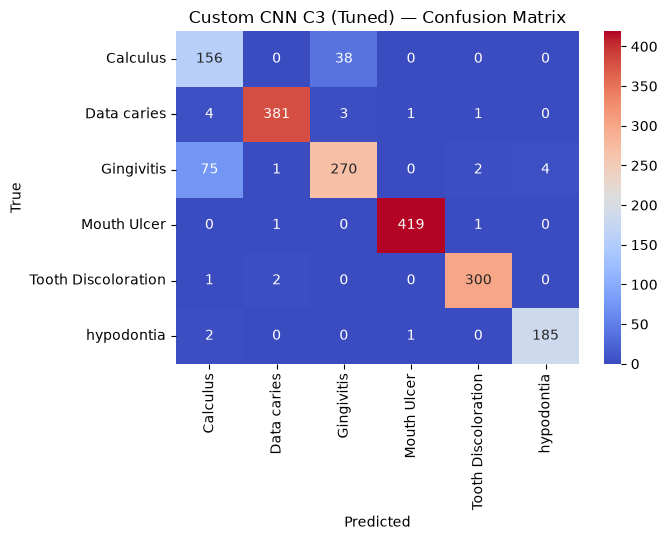

In [9]:
cnn_loss, _ = cnn_c3.evaluate(test_ds, verbose=0)
result_cnn = evaluate_probs(cnn_test_probs, y_test_true, CLASS_NAMES, "Custom CNN C3 (Tuned)", precomputed_loss=cnn_loss)



ResNet50 C2 (Improved) — Test Set Evaluation
  Accuracy: 0.9307 (93.07%)
  Loss:     0.3619

Classification Report:
                     precision    recall  f1-score   support

           Calculus       0.67      0.85      0.75       194
        Data caries       0.99      0.98      0.98       390
         Gingivitis       0.89      0.76      0.82       352
        Mouth Ulcer       1.00      1.00      1.00       421
Tooth Discoloration       0.99      0.99      0.99       303
         hypodontia       0.98      0.98      0.98       188

           accuracy                           0.93      1848
          macro avg       0.92      0.93      0.92      1848
       weighted avg       0.94      0.93      0.93      1848



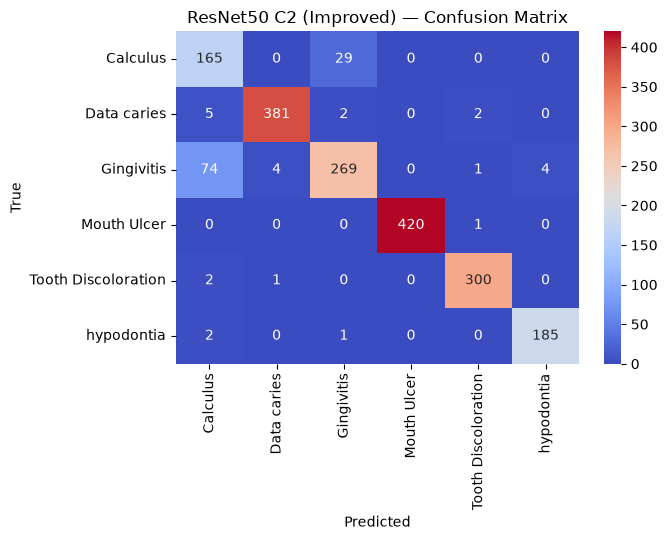

In [10]:
resnet_loss, _ = resnet_c2.evaluate(test_ds, verbose=0)
result_resnet = evaluate_probs(resnet_test_probs, y_test_true, CLASS_NAMES, "ResNet50 C2 (Improved)", precomputed_loss=resnet_loss)


## 5. Ensemble — Simple Average

Average the two models' softmax outputs directly (equal 50/50 weight), then take the argmax as the ensemble prediction. No retraining involved — this only needs the probabilities already computed above.

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring f


Ensemble (Simple Average) — Test Set Evaluation
  Accuracy: 0.9318 (93.18%)
  Loss:     0.1534

Classification Report:
                     precision    recall  f1-score   support

           Calculus       0.67      0.82      0.74       194
        Data caries       0.99      0.98      0.99       390
         Gingivitis       0.88      0.78      0.82       352
        Mouth Ulcer       1.00      1.00      1.00       421
Tooth Discoloration       0.99      0.99      0.99       303
         hypodontia       0.98      0.99      0.99       188

           accuracy                           0.93      1848
          macro avg       0.92      0.93      0.92      1848
       weighted avg       0.94      0.93      0.93      1848



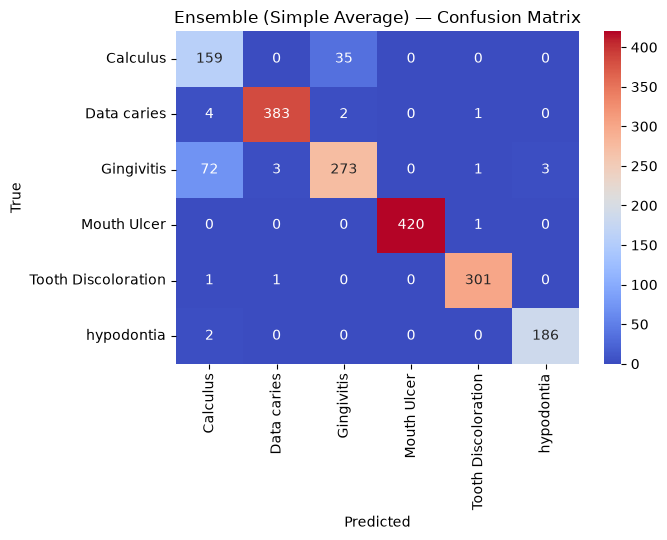

In [11]:
simple_avg_probs = (cnn_test_probs + resnet_test_probs) / 2
result_ensemble_simple = evaluate_probs(simple_avg_probs, y_test_true, CLASS_NAMES, "Ensemble (Simple Average)")
all_results.append(result_ensemble_simple)

## 6. Ensemble — Weighted Average (weight tuned on validation set)

ResNet50 C2 scored higher individually, so it's reasonable to weight it more heavily than the CNN in the blend. Rather than guessing a weight, sweep it on the **validation set** and pick whichever gives the best validation accuracy — the test set is only touched once, afterward, to report the final number.

Best ResNet50 weight (from validation sweep): w = 0.30  ->  Val Acc = 94.21%


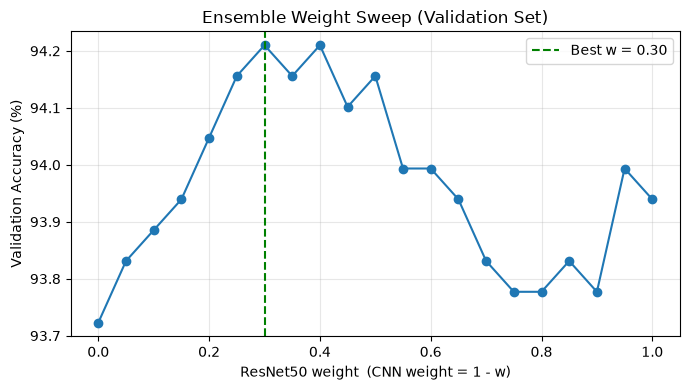

In [12]:
weights = np.arange(0.0, 1.05, 0.05)
val_accuracies = []

for w in weights:
    blended = w * resnet_val_probs + (1 - w) * cnn_val_probs
    pred = np.argmax(blended, axis=1)
    val_accuracies.append((pred == y_val_true).mean())

best_idx = int(np.argmax(val_accuracies))
best_w = float(weights[best_idx])
print(f"Best ResNet50 weight (from validation sweep): w = {best_w:.2f}  ->  Val Acc = {val_accuracies[best_idx]*100:.2f}%")

plt.figure(figsize=(7, 4))
plt.plot(weights, [a * 100 for a in val_accuracies], marker='o')
plt.axvline(best_w, color='green', linestyle='--', label=f'Best w = {best_w:.2f}')
plt.xlabel('ResNet50 weight  (CNN weight = 1 - w)')
plt.ylabel('Validation Accuracy (%)')
plt.title('Ensemble Weight Sweep (Validation Set)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


Ensemble (Weighted, w_ResNet50=0.30) — Test Set Evaluation
  Accuracy: 0.9280 (92.80%)
  Loss:     0.1540

Classification Report:
                     precision    recall  f1-score   support

           Calculus       0.66      0.81      0.73       194
        Data caries       0.99      0.98      0.98       390
         Gingivitis       0.88      0.76      0.82       352
        Mouth Ulcer       1.00      1.00      1.00       421
Tooth Discoloration       0.99      0.99      0.99       303
         hypodontia       0.98      0.99      0.98       188

           accuracy                           0.93      1848
          macro avg       0.91      0.92      0.92      1848
       weighted avg       0.93      0.93      0.93      1848



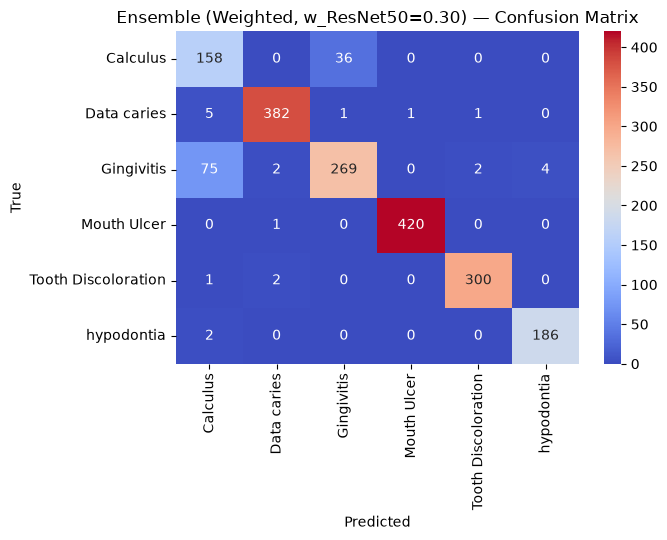

In [13]:
weighted_test_probs = best_w * resnet_test_probs + (1 - best_w) * cnn_test_probs
result_ensemble_weighted = evaluate_probs(
    weighted_test_probs, y_test_true, CLASS_NAMES,
    f"Ensemble (Weighted, w_ResNet50={best_w:.2f})"
)
all_results.append(result_ensemble_weighted)

## 7. Final Comparison Table

In [14]:
comp_df = pd.DataFrame(all_results)
max_test = comp_df['Test Acc (%)'].max()

def highlight_best(row):
    if row['Test Acc (%)'] == max_test:
        return ['background-color: yellow; font-weight: bold'] * len(row)
    return [''] * len(row)

styled = comp_df.style.apply(highlight_best, axis=1)
print("\n" + "="*55)
print("           FINAL MODEL COMPARISON")
print("="*55)
display(styled)

print(comp_df.to_string(index=False))


           FINAL MODEL COMPARISON


,Model,Test Acc (%),Test Loss
0,Ensemble (Simple Average),93.180000,0.153400
1,"Ensemble (Weighted, w_ResNet50=0.30)",92.800000,0.154000


                               Model  Test Acc (%)  Test Loss
           Ensemble (Simple Average)         93.18     0.1534
Ensemble (Weighted, w_ResNet50=0.30)         92.80     0.1540


## 8. Conclusion

*(Fill in after running — the template below shows the structure to follow.)*

- **Best single model:** ResNet50 C2 (Improved) — [test accuracy]%
- **Best overall:** [Ensemble Simple / Ensemble Weighted / ResNet50 C2 alone] — [test accuracy]%
- **Did ensembling help?** State the actual accuracy delta between the best single model and the best ensemble. If the ensemble wins, this matches published findings on this same dataset, where a weighted ensemble of CNN/transformer backbones (96.3%) clearly outperformed any single architecture. If the ensemble does *not* win here, that's still a legitimate, reportable finding — two models built on similar features may already be too correlated in their errors for averaging to add much, which is itself a useful critical-analysis point (Task 3/4).
- **Future improvement:** adding a third, more architecturally different model (e.g. EfficientNetB0 or DenseNet121) to the ensemble is the literature-backed next step if there's time before submission — see the earlier discussion for why standalone Vision Transformers are not worth the effort here.